### Installation

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.57.1
!pip install --no-deps trl==0.22.2

In [ ]:
!pip install --upgrade "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.5.1 requires cut_cross_entropy; python_version >= "3.10", which is not installed.
unsloth-zoo 2026.5.1 requires msgspec, which is not installed.
unsloth-zoo 2026.5.1 requires tyro, which is not installed.
unsloth 2026.5.2 requires tyro, which is not installed.


### Unsloth

In [ ]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

### Data Prep

In [ ]:
from datasets import load_dataset

dataset = load_dataset("naver-clova-ix/cord-v2")

README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

data/train-00002-of-00004-688fe1305a55e5(…):   0%|          | 0.00/444M [00:00<?, ?B/s]

...

data/validation-00000-of-00001-cc3c5779f(…):   0%|          | 0.00/242M [00:00<?, ?B/s]

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Let's take an overview look at the dataset.

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
})

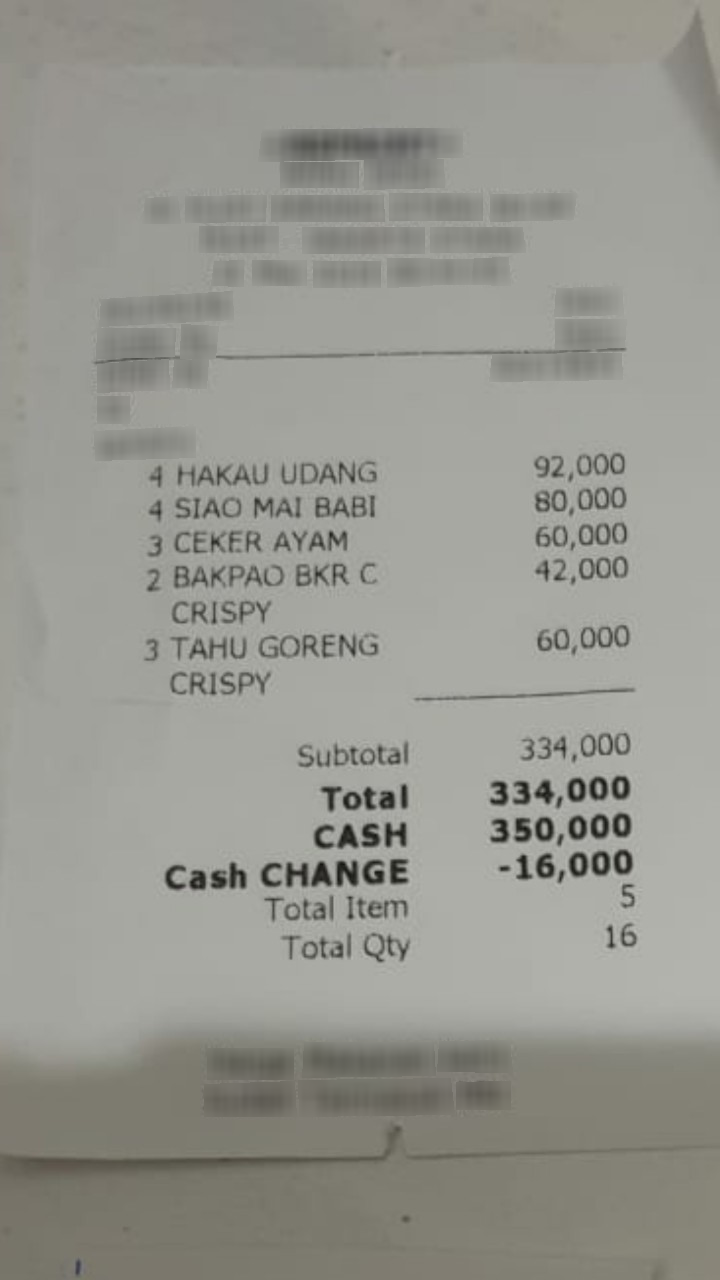

In [ ]:
dataset['train'][2]["image"]

In [ ]:
import json
json.loads(dataset['train'][2]["ground_truth"])["gt_parse"]

{'menu': [{'nm': 'HAKAU UDANG', 'cnt': '4', 'price': '92,000'},
  {'nm': 'SIAO MAI BABI', 'cnt': '4', 'price': '80,000'},
  {'nm': 'CEKER AYAM', 'cnt': '3', 'price': '60,000'},
  {'nm': 'BAKPAO BKR C CRISPY', 'cnt': '2', 'price': '42,000'},
  {'nm': 'TAHU GORENG CRISPY', 'cnt': '3', 'price': '60,000'}],
 'sub_total': {'subtotal_price': '334,000'},
 'total': {'total_price': '334,000',
  'cashprice': '350,000',
  'changeprice': '-16,000',
  'menutype_cnt': '5',
  'menuqty_cnt': '16'}}

Let's convert the dataset into the "correct" format for finetuning:

In [ ]:
import json

instruction = """You are an expert receipt parser.
Analyze the receipt image and extract ALL key information.

Output ONLY a single valid JSON object. Do not add any explanation, markdown, code blocks, or extra text — just the raw JSON.

The JSON must follow this structure (include only fields that actually appear on the receipt):
{
  "menu": [{"nm": "item name", "cnt": "quantity", "price": "item total price"}],
  "sub_total": {"subtotal_price": "...", "tax_price": "...", "discount_price": "...", "service_price": "..."},
  "total": {"total_price": "...", "cashprice": "...", "changeprice": "...", "creditcardprice": "...", "menuqty_cnt": "..."}
}

If a field is missing from the receipt, omit it entirely. Do not add null or empty strings."""

def format_on_the_fly(batch):
    formatted_messages = []

    for img, gt in zip(batch["image"], batch["ground_truth"]):
        gt_parse_dict = json.loads(gt)["gt_parse"]
        gt_parse_string = json.dumps(gt_parse_dict, indent=2, ensure_ascii=False)

        conversation = [
            { "role": "user",
              "content" : [
                {"type" : "text",  "text"  : instruction},
                {"type" : "image", "image" : img}
              ]
            },
            { "role" : "assistant",
              "content" : [
                {"type" : "text",  "text"  : gt_parse_string}
              ]
            },
        ]
        formatted_messages.append(conversation)

    return {"messages": formatted_messages}

dataset.set_transform(format_on_the_fly)


In [ ]:
json.loads(dataset["train"][2]['messages'][1]['content'][0]["text"])

{'menu': [{'nm': 'HAKAU UDANG', 'cnt': '4', 'price': '92,000'},
  {'nm': 'SIAO MAI BABI', 'cnt': '4', 'price': '80,000'},
  {'nm': 'CEKER AYAM', 'cnt': '3', 'price': '60,000'},
  {'nm': 'BAKPAO BKR C CRISPY', 'cnt': '2', 'price': '42,000'},
  {'nm': 'TAHU GORENG CRISPY', 'cnt': '3', 'price': '60,000'}],
 'sub_total': {'subtotal_price': '334,000'},
 'total': {'total_price': '334,000',
  'cashprice': '350,000',
  'changeprice': '-16,000',
  'menutype_cnt': '5',
  'menuqty_cnt': '16'}}

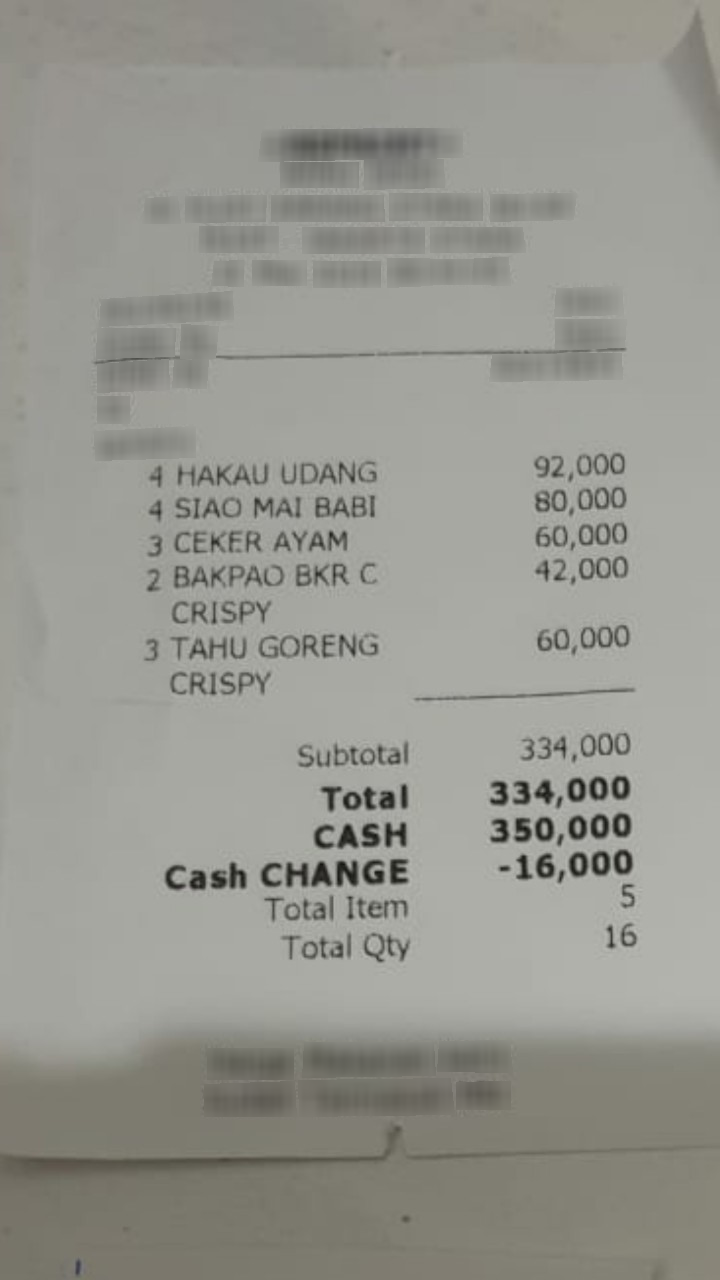

In [ ]:
dataset["train"][2]['messages'][0]['content'][1]['image']

In [ ]:
import json
from typing import Dict, List
import numpy as np

def cord_f1_score(predictions: List[str], references: List[str]) -> Dict[str, float]:
    """
    Order-independent F1 for CORD-V2 JSON output.

    Key fix: menu items are compared as a BAG (set of frozensets) rather than
    by position. This means {"nm": "Coffee", "price": "3000"} is counted as a
    match regardless of whether it appears at index 0 or index 3 in the list.
    """
    total_precision = total_recall = total_f1 = 0.0
    count = 0

    for pred_str, ref_str in zip(predictions, references):
        try:
            pred = json.loads(pred_str)
            ref  = json.loads(ref_str)
        except Exception:
            # Invalid JSON → treat as zero F1 for this sample
            count += 1
            continue

        def flatten_json(obj, prefix=""):
            items = set()
            for k, v in obj.items():
                key = f"{prefix}{k}" if prefix else k
                if isinstance(v, dict):
                    items.update(flatten_json(v, key + "."))
                elif isinstance(v, list):
                    list_repr = set()
                    for item in v:
                        if isinstance(item, dict):
                            # Each dict element → frozenset of its leaf pairs
                            elem_pairs = frozenset(flatten_json(item))
                        else:
                            elem_pairs = frozenset([(key, str(item))])
                        list_repr.add(elem_pairs)
                    # Encode the whole list as one token in the parent set
                    items.add((key, frozenset(list_repr)))
                else:
                    items.add((key, str(v)))
            return items

        pred_set = flatten_json(pred)
        ref_set  = flatten_json(ref)

        if len(ref_set) == 0:
            continue

        tp        = len(pred_set & ref_set)
        precision = tp / len(pred_set) if pred_set else 0.0
        recall    = tp / len(ref_set)
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)

        total_precision += precision
        total_recall    += recall
        total_f1        += f1
        count           += 1

    n = count if count > 0 else 1
    return {
        "f1":        round(total_f1        / n * 100, 2),
        "precision": round(total_precision / n * 100, 2),
        "recall":    round(total_recall    / n * 100, 2),
    }

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    decoded_preds  = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels,      skip_special_tokens=True)
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]
    return cord_f1_score(decoded_preds, decoded_labels)


### Before-Training Baseline Evaluation on Test Set


In [ ]:

import torch, json, time
from tqdm import tqdm
from unsloth.trainer import UnslothVisionDataCollator

def build_prompt_inputs(example, tokenizer, model):
    """Tokenise the user turn only — no assistant answer — for generation."""
    user_turn = example["messages"][0]
    image     = user_turn["content"][1]["image"]
    prompt_messages = [
        {"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": user_turn["content"][0]["text"]},
        ]}
    ]
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, add_generation_prompt=True
    )
    return tokenizer(
        image, prompt_text,
        add_special_tokens=False,
        return_tensors="pt",
    ).to(model.device)


def run_evaluation(model, tokenizer, dataset, split="test", n=100, label=""):
    """
    Evaluate on `n` examples from `split`.
    Returns a dict with metrics + per-sample predictions and references.
    """
    FastVisionModel.for_inference(model)
    model.eval()
    torch.cuda.empty_cache()

    collator   = UnslothVisionDataCollator(model, tokenizer)
    subset     = dataset[split].select(range(min(n, len(dataset[split]))))
    all_preds  = []
    references = []
    total_loss = 0.0
    n_batches  = 0
    start      = time.time()

    print(f"\n{'='*60}")
    print(f"  Evaluating: {label}  |  split={split}  |  n={len(subset)}")
    print(f"{'='*60}")

    for i, example in enumerate(tqdm(subset, desc=label)):

        with torch.no_grad():
            loss_batch = collator([example])
            loss_batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v
                          for k, v in loss_batch.items()}
            out = model(**loss_batch)
            if hasattr(out, "loss") and out.loss is not None:
                total_loss += out.loss.item()
            n_batches += 1
            del loss_batch, out
            torch.cuda.empty_cache()

        with torch.no_grad():
            gen_in      = build_prompt_inputs(example, tokenizer, model)
            input_len   = gen_in["input_ids"].shape[1]
            gen_ids     = model.generate(
                **gen_in,
                max_new_tokens=256,
                do_sample=False,
                temperature=1.0,
                top_p=1.0,
                use_cache=True,
            )
            new_ids     = gen_ids[0][input_len:]
            pred        = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
            if pred.startswith("```"):
                pred = pred.replace("```json", "").replace("```", "").strip()
            all_preds.append(pred)
            del gen_in, gen_ids
            torch.cuda.empty_cache()

        # Ground truth
        references.append(example["messages"][1]["content"][0]["text"])

    metrics = cord_f1_score(all_preds, references)
    metrics["loss"] = round(total_loss / n_batches, 4) if n_batches else 0.0
    metrics["preds"] = all_preds
    metrics["refs"]  = references
    metrics["time_min"] = round((time.time() - start) / 60, 1)
    return metrics



EVAL_N = 100

before_metrics = run_evaluation(
    model, tokenizer, dataset,
    split="test", n=EVAL_N, label="BEFORE training"
)

print(f"\nBEFORE  |  Loss: {before_metrics['loss']:.4f}  |  "
      f"F1: {before_metrics['f1']:.2f}%  |  "
      f"Precision: {before_metrics['precision']:.2f}%  |  "
      f"Recall: {before_metrics['recall']:.2f}%")
print("Results saved → before_metrics  (run after-training cell when ready)")


Unsloth: Model does not have a default image size - using 512

  Evaluating: BEFORE training  |  split=test  |  n=100


BEFORE training: 100%|██████████| 100/100 [1:05:34<00:00, 39.35s/it]


BEFORE  |  Loss: 1.8838  |  F1: 49.94%  |  Precision: 54.37%  |  Recall: 47.87%
Results saved → before_metrics  (run after-training cell when ready)


### Train the model

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = dataset["train"],
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 10,
        learning_rate = 5e-5,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)


Unsloth: Model does not have a default image size - using 512


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 800 | Num Epochs = 1 | Total steps = 10
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,1.735300
2,1.770200
3,2.060300
4,1.936400
5,1.722100
6,1.600600
7,1.225300
8,0.971100
9,1.308700
10,1.123400


### After-Training Evaluation + Before vs After Comparison

In [ ]:
after_metrics = run_evaluation(
    model, tokenizer, dataset,
    split="test", n=EVAL_N, label="AFTER training"
)

def delta(after, before):
    d = after - before
    sign = "+" if d >= 0 else ""
    return f"{sign}{d:.2f}"

print("\n" + "═"*62)
print("  BEFORE vs AFTER FINE-TUNING  —  Test Set Comparison")
print("═"*62)
print(f"  {'Metric':<28} {'Before':>8}  {'After':>8}  {'Δ':>8}")
print("─"*62)
print(f"  {'Loss (↓ better)':<28} {before_metrics['loss']:>8.4f}  {after_metrics['loss']:>8.4f}  {delta(after_metrics['loss'], before_metrics['loss']):>8}")
print(f"  {'F1 Score  % (↑ better)':<28} {before_metrics['f1']:>8.2f}  {after_metrics['f1']:>8.2f}  {delta(after_metrics['f1'], before_metrics['f1']):>8}")
print(f"  {'Precision % (↑ better)':<28} {before_metrics['precision']:>8.2f}  {after_metrics['precision']:>8.2f}  {delta(after_metrics['precision'], before_metrics['precision']):>8}")
print(f"  {'Recall    % (↑ better)':<28} {before_metrics['recall']:>8.2f}  {after_metrics['recall']:>8.2f}  {delta(after_metrics['recall'], before_metrics['recall']):>8}")
print("─"*62)
print(f"  {'Eval time (min)':<28} {before_metrics['time_min']:>8.1f}  {after_metrics['time_min']:>8.1f}")
print("═"*62)


Unsloth: Model does not have a default image size - using 512

  Evaluating: AFTER training  |  split=test  |  n=100


AFTER training: 100%|██████████| 100/100 [1:04:15<00:00, 38.56s/it]


══════════════════════════════════════════════════════════════
  BEFORE vs AFTER FINE-TUNING  —  Test Set Comparison
══════════════════════════════════════════════════════════════
  Metric                         Before     After         Δ
──────────────────────────────────────────────────────────────
  Loss (↓ better)                1.8838    1.2590     -0.62
  F1 Score  % (↑ better)          49.94     50.59     +0.65
  Precision % (↑ better)          54.37     55.04     +0.67
  Recall    % (↑ better)          47.87     48.52     +0.65
──────────────────────────────────────────────────────────────
  Eval time (min)                  65.6      64.3
══════════════════════════════════════════════════════════════


### Inference

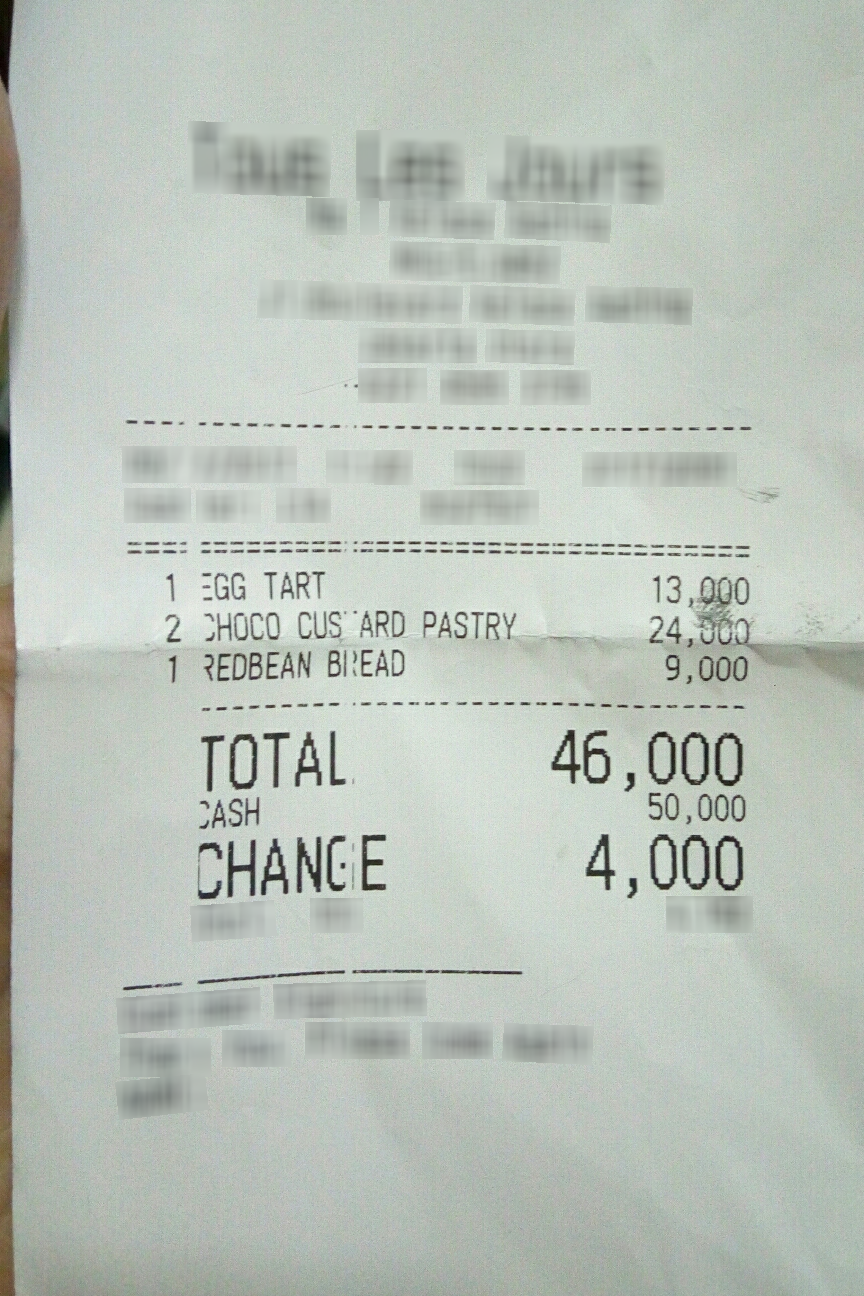

In [ ]:
dataset["test"][6]['messages'][0]['content'][1]['image']

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!

image = dataset["test"][6]['messages'][0]['content'][1]['image']
instruction = """You are an expert receipt parser.
Analyze the receipt image and extract ALL key information.

Output ONLY a single valid JSON object. Do not add any explanation, markdown, code blocks, or extra text — just the raw JSON.

The JSON must follow this structure (include only fields that actually appear on the receipt):
{
  "menu": [{"nm": "item name", "cnt": "quantity", "price": "item total price"}],
  "sub_total": {"subtotal_price": "...", "tax_price": "...", "discount_price": "...", "service_price": "..."},
  "total": {"total_price": "...", "cashprice": "...", "changeprice": "...", "creditcardprice": "...", "menuqty_cnt": "..."}
}

If a field is missing from the receipt, omit it entirely. Do not add null or empty strings."""

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 512,
                   use_cache = True, temperature = 1.5, min_p = 0.1)



{
  "menu": [
    {
      "nm": "EGG TART",
      "cnt": "1",
      "price": "13,000"
    },
    {
      "nm": "CHOCO CUS'ARD PASTRY",
      "cnt": "2",
      "price": "24,000"
    },
    {
      "nm": "REDBEAN BREAD",
      "cnt": "1",
      "price": "9,000"
    }
  ],
  "total": {
    "total_price": "46,000",
    "cashprice": "50,000",
    "changeprice": "4,000"
  }
}<|im_end|>


In [ ]:
print("Ground Truth:\n")
json.loads(dataset["test"][6]['messages'][1]['content'][0]["text"])

Ground Truth:



{'menu': [{'nm': 'EGG TART', 'cnt': '1', 'price': '13,000'},
  {'nm': 'CHOCO CUS ARD PASTRY', 'cnt': '2', 'price': '24,000'},
  {'nm': 'REDBEAN BREAD', 'cnt': '1', 'price': '9,000'}],
 'total': {'total_price': '46,000',
  'cashprice': '50,000',
  'changeprice': '4,000'}}

### Saving finetuned models

In [ ]:
from google.colab import userdata
HF_TOKEN_WRITE= userdata.get('HF_TOKEN_WRITE')


model.push_to_hub("MarioMamdouh121/qwen_lora", token = HF_TOKEN_WRITE)
tokenizer.push_to_hub("MarioMamdouh121/qwen_lora", token = HF_TOKEN_WRITE)

[]